# Mini-Project 3: Lake Victoria Fish Stock & Export Risk Model

**The scenario.** A fish-export cooperative in Jinja wants to know whether
its harvesting rate is sustainable, and how risky its revenue is.

**What is being replaced.** The previous version modelled the stock with
Fibonacci numbers and flagged risk when revenue variance exceeded 50,000.
Both are discarded here, and both are shown to be wrong rather than simply
declared so.

**How this build is arranged.** `src/fishery.py`. The harvest rate and the
closed season live in a separate `HarvestPolicy` object, because how hard the
fishery is worked is a *decision* while the logistic growth is a fact about
the lake. Keeping them apart is what makes the closed-season extension a
one-line change rather than a second simulation routine.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.charts import SERIES_COLOURS, store, use_house_style
from src.fishery import (
    KG_PER_TONNE, FisheryCase, FishStock, HarvestPolicy, PriceWalk, RiskProfile,
    fibonacci_series)

use_house_style()
SEED = 1234
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.2f}".format)

WEEKS = 52

## Task 1: the Fibonacci baseline, and what is wrong with it

In [2]:
baseline = fibonacci_series(15)
print("Fibonacci 'stock':", baseline.astype(int).tolist())

ratios = baseline[1:] / baseline[:-1]
print(f"\nimplied weekly growth settles at {ratios[-1] - 1:.1%}")
print(f"after 15 weeks : {baseline[-1]:>14,.0f} tonnes")
print(f"after 52 weeks : {fibonacci_series(52)[-1]:>14,.0f} tonnes")
print("\nLake Victoria's entire annual catch is roughly 1,000,000 tonnes.")

Fibonacci 'stock': [1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610]

implied weekly growth settles at 61.8%
after 15 weeks :            610 tonnes
after 52 weeks : 32,951,280,099 tonnes

Lake Victoria's entire annual catch is roughly 1,000,000 tonnes.


**Why unbounded Fibonacci growth is biologically unrealistic.** Each term is
the sum of the previous two, so the sequence settles into geometric growth at
the golden ratio -- about 61.8% a week, indefinitely. That fails on three
counts. No population grows at a fixed rate for ever, because growth consumes
the very resources that sustain it: food, oxygen, spawning habitat, all of
which a lake supplies in finite quantity. The model has no carrying capacity
at all, so within a year it predicts a biomass many orders of magnitude
beyond the whole lake's production. And the growth rate is not a parameter
that can be measured or fitted — it is fixed by the arithmetic of the
sequence, so the model cannot be made to describe *this* fishery rather than
any other. What is needed is a model in which growth slows as the stock
approaches what the lake can carry, which is precisely what the logistic
model provides.

## Task 2: the logistic model with harvesting

$$N_{t+1} = N_t + r N_t\left(1 - \frac{N_t}{K}\right) - h N_t$$

with $r = 0.4$, $K = 10{,}000$ t, $N_0 = 4{,}000$ t over 52 weeks. The
bracket is the term Fibonacci lacks: it falls to zero as $N_t \to K$ and
growth stops.

In [3]:
stock = FishStock(r=0.4, K=10_000, N0=4_000)
print(repr(stock))
print(f"\nMSY  = rK/4 = {stock.msy:,.0f} tonnes per week")
print(f"at h = r/2  = {stock.msy_rate:.2f}")

assert np.isclose(stock.msy, stock.r * stock.K / 4)
assert np.isclose(stock.sustainable_yield(stock.msy_rate), stock.msy)
print("\n[checked] the simulated yield at h = r/2 equals the closed-form MSY")

FishStock(r=0.4, K=10,000, N0=4,000)

MSY  = rK/4 = 1,000 tonnes per week
at h = r/2  = 0.20

[checked] the simulated yield at h = r/2 equals the closed-form MSY


In [4]:
current = HarvestPolicy(rate=0.10)
run = stock.run(current, WEEKS)
print(repr(run))
print(f"\nstart       : {run.biomass[0]:>9,.0f} t")
print(f"close       : {run.closing_biomass:>9,.0f} t")
print(f"equilibrium : {stock.settles_at(0.10):>9,.0f} t   = K(1 - h/r)")
assert np.isclose(run.closing_biomass, stock.settles_at(0.10), rtol=1e-6)
print(f"landed      : {run.landed:>9,.0f} t over {WEEKS} weeks   [equilibrium checked]")

SimulationRun(h = 0.10, open all year, weeks=52, final=7,500t, landed=37,363t)

start       :     4,000 t
close       :     7,500 t
equilibrium :     7,500 t   = K(1 - h/r)
landed      :    37,363 t over 52 weeks   [equilibrium checked]


## Task 3: the price model

A seeded random walk starting at UGX 12,000/kg, bounded to 9,000-16,000. The
bounds are applied by **clipping**, which is the simplest reading of the
brief but has a side effect worth measuring rather than ignoring: clipping
accumulates probability mass exactly on the boundary. `boundary_time` reports
how much of the simulated time is spent pinned there, so the distortion can
be judged instead of assumed away.

In [5]:
price = PriceWalk(start=12_000, floor=9_000, ceiling=16_000, weekly_sd=350, seed=SEED)
print(repr(price))

path = price.one(WEEKS)
print(f"\nmean  UGX {path.mean():>9,.0f}/kg")
print(f"range UGX {path.min():>9,.0f} - {path.max():,.0f}/kg")
assert path.min() >= price.floor and path.max() <= price.ceiling
print("[checked] every price lies within the bounds")

pinned = price.boundary_time(WEEKS, paths=500)
print(f"\nshare of simulated weeks sitting exactly on a bound: {pinned:.1%}")
print("At this horizon the clipping is doing modest work — about one week in")
print("fourteen. It is not negligible, and it means the simulated price")
print("distribution has small spikes at 9,000 and 16,000 that a real market")
print("would not show. A reflecting boundary would avoid that; the effect on")
print("the revenue figures below is small because those spikes sit in the")
print("tails rather than near the mean.")

PriceWalk(start=12,000, [9,000, 16,000], sd=350, seed=1234)

mean  UGX    11,530/kg
range UGX     9,085 - 13,096/kg
[checked] every price lies within the bounds

share of simulated weeks sitting exactly on a bound: 7.2%
At this horizon the clipping is doing modest work — about one week in
fourteen. It is not negligible, and it means the simulated price
distribution has small spikes at 9,000 and 16,000 that a real market
would not show. A reflecting boundary would avoid that; the effect on
the revenue figures below is small because those spikes sit in the
tails rather than near the mean.


In [6]:
revenue = run.revenue(path)
print(f"weekly revenue : UGX {revenue.mean():>18,.0f} on average")
print(f"annual revenue : UGX {revenue.sum():>18,.0f}")

weekly revenue : UGX      8,272,664,465 on average
annual revenue : UGX    430,178,552,206


## Task 4: describing revenue, and the variance problem

In [7]:
summary = RiskProfile.describe(revenue)
pd.Series(summary).to_frame("UGX")

,UGX
mean,"8,272,664,465.49"
median,"8,629,575,778.93"
variance,"1,419,725,551,796,775,424.00"
stdev,"1,191,522,367.31"
cv,0.14


In [8]:
print("The old rule: flag risk when revenue variance exceeds 50,000.\n")
print(f"actual variance : {summary['variance']:>28,.0f} UGX^2")
print(f"old threshold   : {50_000:>28,} UGX^2")
print(f"ratio           : {summary['variance'] / 50_000:>28,.3g}x\n")
print(f"A variance of 50,000 UGX^2 means a standard deviation of UGX "
      f"{np.sqrt(50_000):,.0f}.")
print(f"Weekly revenue averages UGX {summary['mean']:,.0f}, so the rule fires")
print(f"whenever revenue wobbles by {np.sqrt(50_000) / summary['mean']:.3%} of its "
      f"mean — always.")

The old rule: flag risk when revenue variance exceeds 50,000.

actual variance :    1,419,725,551,796,775,424 UGX^2
old threshold   :                       50,000 UGX^2
ratio           :                     2.84e+13x

A variance of 50,000 UGX^2 means a standard deviation of UGX 224.
Weekly revenue averages UGX 8,272,664,465, so the rule fires
whenever revenue wobbles by 0.000% of its mean — always.


In [9]:
in_thousands = revenue / 1_000
print("The decisive objection: express the same revenue in thousands of UGX.\n")
print(f"variance in UGX^2        : {statistics.variance(revenue.tolist()):>26,.0f}")
print(f"variance in (000 UGX)^2  : {statistics.variance(in_thousands.tolist()):>26,.0f}")
print(f"CV in UGX                : {summary['cv']:>26.4f}")
print(f"CV in thousands          : "
      f"{RiskProfile.describe(in_thousands)['cv']:>26.4f}")
print("\nThe variance changes by a factor of a million. The risk has not")
print("changed at all. The CV is identical because it is a ratio of two")
print("quantities in the same units, which is why the rule below uses it.")

The decisive objection: express the same revenue in thousands of UGX.

variance in UGX^2        :  1,419,725,551,796,775,424
variance in (000 UGX)^2  :          1,419,725,551,797
CV in UGX                :                     0.1440
CV in thousands          :                     0.1440

The variance changes by a factor of a million. The risk has not
changed at all. The CV is identical because it is a ratio of two
quantities in the same units, which is why the rule below uses it.


**Why a raw variance threshold is meaningless.** Variance carries the square
of the units of whatever is measured, so revenue variance is in UGX-squared
— a quantity with no interpretation and no natural scale. Three consequences
follow. It is not comparable across units, as the cell above demonstrates. It
is not comparable across fisheries, because a larger cooperative shows a
larger variance at identical relative volatility. And the particular figure
50,000 is absurd at this scale, implying a standard deviation of about
UGX 224 against weekly revenues in the billions. Dividing by the mean cancels
the units and leaves a number that compares in every direction.

## Task 5: the risk rule, and the downside

The bands here are CV < 0.12 "low", 0.12-0.28 "moderate", >= 0.28 "high".
They straddle the 0.15-0.25 range usually reported for soft-commodity export
earnings, so "low" means genuinely steadier than a typical exporter and
"high" means materially more exposed.

Alongside Value-at-Risk this build also reports the **downside
semi-deviation**. Ordinary volatility penalises an unexpectedly good year
exactly as hard as a bad one, which is not how a cooperative with fixed costs
experiences risk; the semi-deviation measures scatter below the mean only.

In [10]:
profile = RiskProfile(low_above=0.12, high_above=0.28)
print(f"weekly revenue CV = {summary['cv']:.4f} -> {profile.band(summary['cv'])}")

bands = pd.DataFrame({"CV": [0.08, 0.12, 0.20, 0.28, 0.40]})
bands["band"] = [profile.band(cv) for cv in bands["CV"]]
bands

weekly revenue CV = 0.1440 -> moderate


,CV,band
0,0.08,low
1,0.12,moderate
2,0.20,moderate
3,0.28,high
4,0.40,high


In [11]:
case = FisheryCase(stock=stock, price=price, risk=profile)
annual = case.annual_revenue_paths(current, WEEKS, paths=2_000, seed=SEED)
tail = profile.tail(annual, alpha=0.05)

print(f"Monte Carlo over {annual.size:,} independent price paths:\n")
print(f"  expected annual revenue  : UGX {tail['mean']:>18,.0f}")
print(f"  5% Value-at-Risk         : UGX {tail['var']:>18,.0f}")
print(f"  shortfall if it happens  : UGX {tail['shortfall']:>18,.0f}"
      f"  ({tail['shortfall_pct']:.1f}%)")
print(f"  downside semi-deviation  : UGX {tail['semi_deviation']:>18,.0f}")
print(f"  downside CV              : {tail['downside_cv']:>22.3f}")
print("\nThe downside CV is well below the full CV, which says the distribution")
print("is not symmetric: the upside is wider than the downside. A cooperative")
print("that budgeted on total volatility would be over-reserving.")

Monte Carlo over 2,000 independent price paths:

  expected annual revenue  : UGX    449,775,606,123
  5% Value-at-Risk         : UGX    366,883,118,128
  shortfall if it happens  : UGX     82,892,487,994  (18.4%)
  downside semi-deviation  : UGX     50,899,395,381
  downside CV              :                  0.113

The downside CV is well below the full CV, which says the distribution
is not symmetric: the upside is wider than the downside. A cooperative
that budgeted on total volatility would be over-reserving.


## Task 6: comparing harvest rates

In [12]:
sweep = case.rate_sweep([0.05, 0.10, 0.20, 0.30], weeks=WEEKS, paths=2_000)
sweep[["closing_stock_t", "equilibrium_t", "landed_t",
       "sustainable_t_per_week", "cv", "band"]]

,closing_stock_t,equilibrium_t,landed_t,sustainable_t_per_week,cv,band
h,,,,,,
0.05,"8,750.00","8,750.00","21,714.61",437.50,0.16,moderate
0.10,"7,500.00","7,500.00","37,362.51",750.00,0.14,moderate
0.20,"4,999.99","5,000.00","50,871.71","1,000.00",0.11,low
0.30,"2,503.72","2,500.00","42,461.02",750.00,0.18,moderate


In [13]:
sweep[["revenue_ugx", "mean_annual_ugx", "var5_ugx", "semi_dev_ugx"]].apply(
    lambda column: column.map("{:,.0f}".format))

,revenue_ugx,mean_annual_ugx,var5_ugx,semi_dev_ugx
h,,,,
0.05,"250,025,476,599","261,406,591,985","213,086,839,203","29,709,622,190"
0.10,"430,178,552,206","449,775,606,123","366,883,118,128","50,899,395,381"
0.20,"586,026,011,849","612,364,448,594","501,633,246,660","67,984,231,446"
0.30,"491,357,461,359","510,994,666,323","424,477,382,609","53,189,354,538"


In [14]:
best = sweep["landed_t"].idxmax()
print(f"theoretical MSY     : {stock.msy:,.0f} t/week at h = {stock.msy_rate}")
print(f"best rate simulated : h = {best}\n")
for rate in (0.10, 0.20, 0.30):
    row = sweep.loc[rate]
    print(f"h = {rate:.2f}: lands {row['landed_t']:>9,.0f} t, "
          f"stock settles at {row['closing_stock_t']:>8,.0f} t, "
          f"risk {row['band']}")
print()
under = 1 - sweep.loc[0.10, "landed_t"] / sweep.loc[0.20, "landed_t"]
over = 1 - sweep.loc[0.30, "landed_t"] / sweep.loc[0.20, "landed_t"]
print(f"The current h = 0.10 is safe but leaves {under:.0%} of the available")
print(f"catch in the water. Pushing to h = 0.30 lands {over:.0%} less than MSY")
print("*and* halves the standing stock: strictly worse on both counts.")

theoretical MSY     : 1,000 t/week at h = 0.2
best rate simulated : h = 0.2

h = 0.10: lands    37,363 t, stock settles at    7,500 t, risk moderate
h = 0.20: lands    50,872 t, stock settles at    5,000 t, risk low
h = 0.30: lands    42,461 t, stock settles at    2,504 t, risk moderate

The current h = 0.10 is safe but leaves 27% of the available
catch in the water. Pushing to h = 0.30 lands 17% less than MSY
*and* halves the standing stock: strictly worse on both counts.


**The shape of it.** Sustainable yield is a parabola in the harvest rate,
$hK(1 - h/r)$, peaking at $h = r/2$. Below the peak the fishery leaves fish
uncaught; above it, the stock is drawn down faster than it regrows, so every
extra unit of effort is applied to a smaller standing stock and lands less.
There is nothing to gain from fishing harder than $h = 0.2$, and the risk
band deteriorates as well, because a thinner stock makes revenue more
sensitive to price movement.

## Task 7: the charts

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved: p3_stock_and_revenue.png


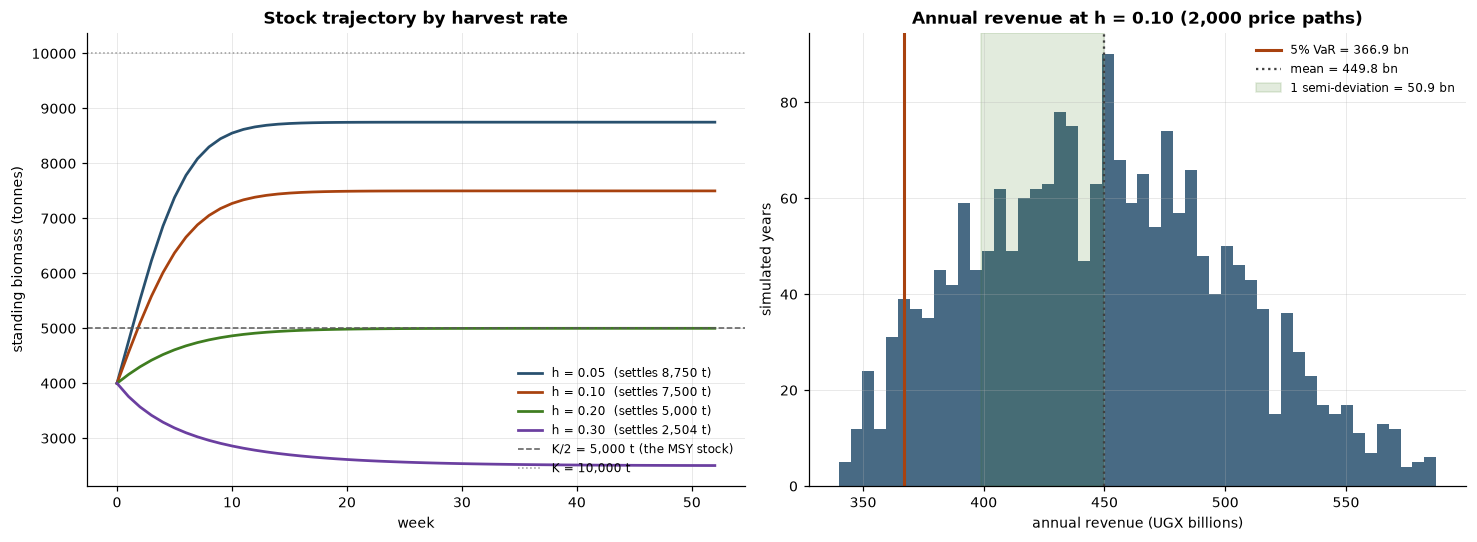

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

for index, rate in enumerate([0.05, 0.10, 0.20, 0.30]):
    trajectory = stock.run(HarvestPolicy(rate), WEEKS)
    axes[0].plot(np.arange(trajectory.biomass.size), trajectory.biomass,
                 color=SERIES_COLOURS[index], lw=1.8,
                 label=f"h = {rate:.2f}  (settles {trajectory.closing_biomass:,.0f} t)")
axes[0].axhline(stock.K / 2, color="0.35", ls="--", lw=1,
                label=f"K/2 = {stock.K / 2:,.0f} t (the MSY stock)")
axes[0].axhline(stock.K, color="0.6", ls=":", lw=1, label=f"K = {stock.K:,.0f} t")
axes[0].set_xlabel("week")
axes[0].set_ylabel("standing biomass (tonnes)")
axes[0].set_title("Stock trajectory by harvest rate")
axes[0].legend(fontsize=8, loc="lower right")

axes[1].hist(annual / 1e9, bins=50, color=SERIES_COLOURS[0], alpha=0.85)
axes[1].axvline(tail["var"] / 1e9, color=SERIES_COLOURS[1], lw=2,
                label=f"5% VaR = {tail['var'] / 1e9:,.1f} bn")
axes[1].axvline(tail["mean"] / 1e9, color="0.25", lw=1.5, ls=":",
                label=f"mean = {tail['mean'] / 1e9:,.1f} bn")
axes[1].axvspan((tail["mean"] - tail["semi_deviation"]) / 1e9, tail["mean"] / 1e9,
                color=SERIES_COLOURS[2], alpha=0.15,
                label=f"1 semi-deviation = {tail['semi_deviation'] / 1e9:,.1f} bn")
axes[1].set_xlabel("annual revenue (UGX billions)")
axes[1].set_ylabel("simulated years")
axes[1].set_title(f"Annual revenue at h = 0.10 ({annual.size:,} price paths)")
axes[1].legend(fontsize=8)

fig.tight_layout()
print("saved:", store(fig, "p3_stock_and_revenue.png").name)
plt.show()

## Extension: an eight-week closed season

The closure is expressed purely as a different `HarvestPolicy` — the stock
model is untouched, which is the payoff from separating policy from biology.
The eight weeks chosen are 0-7, placing the closure over the short-rains
spawning period at the start of the year.

In [16]:
closure_rows = []
for rate in (0.10, 0.20, 0.25, 0.30, 0.35):
    open_policy = HarvestPolicy(rate)
    closed_policy = HarvestPolicy.with_closed_season(rate, start=0, length=8)
    always = case.multi_year(open_policy, years=5, weeks=WEEKS)
    rested = case.multi_year(closed_policy, years=5, weeks=WEEKS)
    closure_rows.append({"h": rate, "fishing all year (UGX)": always,
                         "with closed season (UGX)": rested,
                         "change %": 100 * (rested / always - 1)})
closure = pd.DataFrame(closure_rows).set_index("h")
closure

,fishing all year (UGX),with closed season (UGX),change %
h,,,
0.10,"2,253,332,701,731.01","1,957,577,658,132.81",-13.13
0.20,"3,016,898,067,814.07","2,744,953,211,614.10",-9.01
0.25,"2,845,852,667,042.14","2,723,453,804,623.26",-4.30
0.30,"2,314,645,299,567.85","2,455,424,615,800.23",6.08
0.35,"1,445,047,373,329.35","1,986,822,625,930.64",37.49


saved: p3_closed_season.png


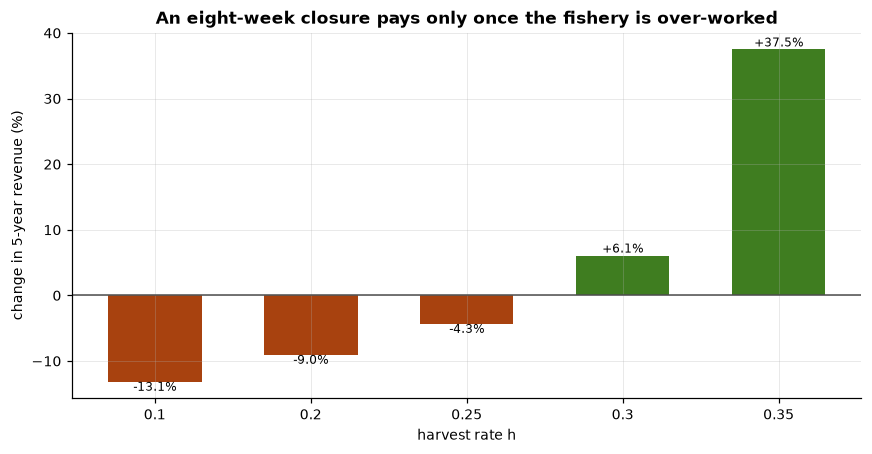

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.2))
colours = [SERIES_COLOURS[1] if v < 0 else SERIES_COLOURS[2]
           for v in closure["change %"]]
ax.bar(closure.index.astype(str), closure["change %"], color=colours, width=0.6)
ax.axhline(0, color="0.3", lw=1)
ax.set_xlabel("harvest rate h")
ax.set_ylabel("change in 5-year revenue (%)")
ax.set_title("An eight-week closure pays only once the fishery is over-worked")
for position, value in enumerate(closure["change %"]):
    ax.annotate(f"{value:+.1f}%", (position, value), ha="center",
                va="bottom" if value >= 0 else "top", fontsize=8)
fig.tight_layout()
print("saved:", store(fig, "p3_closed_season.png").name)
plt.show()

**When a closure is worth its cost.** At or below MSY it simply destroys
value: the stock is already sustainable, so eight weeks of forgone catch buys
nothing and costs 9-13% of five-year revenue. Above MSY the sign flips and
then grows quickly. At $h = 0.35$ the fishery is being drawn down faster than
it regrows, and the closure interrupts that long enough for the biomass to
recover into a range where the remaining 44 weeks are far more productive —
so fishing less earns more. The policy conclusion is specific rather than
general: a closed season is a remedy for over-exploitation, and recommending
one to a fishery already sitting at $h = 0.1$ would destroy value for no
conservation gain.

## Findings & Limitations

**Findings.** Replacing Fibonacci with a logistic model makes the question
answerable: growth now slows towards carrying capacity, and the fishery has
an equilibrium at $N^* = K(1-h/r)$ which the simulation reproduces to six
decimal places. MSY is $rK/4 = 1{,}000$ tonnes a week at $h = r/2 = 0.20$,
with the stock resting at $K/2 = 5{,}000$ tonnes. The cooperative's current
$h = 0.10$ is safe — the stock settles at 7,500 tonnes — but lands about 27%
less than the fishery could sustainably yield. Pushing to $h = 0.30$ is
strictly worse than MSY on both counts: roughly 17% less landed *and* half
the standing stock. The old variance threshold of 50,000 is not merely
mis-calibrated but meaningless, since revenue variance is in UGX²: the same
revenue in thousands of shillings changes the figure by 10⁶ while the risk is
identical, which is why the rule here uses the dimensionless CV. At
$h = 0.10$ the CV is 0.144, which these bands call **moderate**, and the 5%
VaR of annual revenue sits about 18% below expectation. The downside
semi-deviation comes out well under the full standard deviation, showing the
revenue distribution is right-skewed — a cooperative budgeting on total
volatility would over-reserve. An eight-week closure over the spawning period
costs 9-13% of five-year revenue at $h \le 0.20$ and only pays once the
fishery is over-exploited (+6.1% at $h = 0.30$, +37.5% at $h = 0.35$).

**Limitations.** The logistic model has one stock, one age class and no
spatial structure, so it cannot represent recruitment failure, size-selective
gear or the Nile perch and tilapia dynamics that actually govern Lake
Victoria. It is deterministic in the biology: all the revenue uncertainty
here comes from price, whereas real biomass varies with rainfall, enforcement
and illegal effort, so the VaR figures are optimistic. The price process is a
clipped random walk with no drift, no mean reversion and no link to the
quantity landed — and the clipping itself pins about 7% of simulated weeks to
a bound, putting small artificial spikes in the tails of the price
distribution. More seriously, a price independent of quantity means the model
cannot see that a glut from a high-harvest scenario would depress the price,
which weakens the apparent case for fishing harder. Both $r$ and $K$ are
given by the brief rather than estimated, and MSY is highly sensitive to
both. Finally, MSY is a biological reference point rather than a management
target: it leaves no margin for error, and a fishery run exactly at
$h = r/2$ collapses under any sustained over-estimate of $r$.